In [63]:
import matflow
import matplotlib.pyplot as plt
import numpy as np
import damask
import sklearn
from matplotlib.ticker import AutoMinorLocator

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = 'Nimbus Roman'

In [2]:
def extract_stress_strain_hdf5(file, rve_shape):
    result = damask.Result(file)

    try:
        result.add_strain()
        result.add_stress_Cauchy()
        result.add_IPF_color(l=(0,0,1))
    except:
        pass

    stress = []
    strain = []

    for increment in result.increments:
        
        x = result.view(increments = increment)
        
        stress.append(np.mean(x.place('sigma')[:,0,0].reshape(rve_shape,order='F')))
        strain.append(np.mean(x.place('epsilon_V^0.0(F)')[:,0,0].reshape(rve_shape,order='F')))
    
    return strain, stress

In [ ]:
#dislo_wk = './dislo_density/5k_time_steps/dislotwin_32_rolled_copper_2026-06-02_094034'
#pheno_wk = './phenopowerlaw/5k_time_steps/phenopowerlaw_32_rolled_copper_2026-06-02_164459'
#dislo_file = './dislo_density/5k_time_steps/dislotwin_32_rolled_copper_2026-06-02_094034/execute/t_1/geom_load.hdf5'
#pheno_file = './phenopowerlaw/5k_time_steps/phenopowerlaw_32_rolled_copper_2026-06-02_164459/execute/t_1/geom_load.hdf5'

In [ ]:
#dislo_50k_wk = './dislo_density/50k_time_steps/dislotwin_32_rolled_copper_2026-06-01_161956'
#dislo_50k_file = './dislo_density/50k_time_steps/dislotwin_32_rolled_copper_2026-06-01_161956/execute/t_1/geom_load.hdf5'
#pheno_50k_wk = './phenopowerlaw/50k_time_steps/phenopowerlaw_32_rolled_copper_2026-06-03_094157'
#pheno_50k_file = './phenopowerlaw/50k_time_steps/phenopowerlaw_32_rolled_copper_2026-06-03_094157/execute/t_1/geom_load.hdf5'

In [3]:
dislo_file = './dislo_density/second_year_report_calibrated_values/dislotwin_32_rolled_copper_2026-06-19_120653/execute/t_1/geom_load.hdf5'#/second_year_report_calibrated_values/'
pheno_file = './phenopowerlaw/second_year_report_calibrated_values/phenopowerlaw_32_rolled_copper_2026-06-19_120033/execute/t_1/geom_load.hdf5'#second_year_report_calibrated_values/'

In [4]:
dislo_32_true_strain, dislo_32_true_stress = extract_stress_strain_hdf5(file = dislo_file, rve_shape=[32,32,32])
pheno_32_true_strain, pheno_32_true_stress = extract_stress_strain_hdf5(file = pheno_file, rve_shape=[32,32,32])

In [ ]:
#dislo_32_50k_true_strain, dislo_32_50k_true_stress = extract_stress_strain_hdf5(file = dislo_50k_file, rve_shape=[32,32,32])
#pheno_32_50k_true_strain, pheno_32_50k_true_stress = extract_stress_strain_hdf5(file = pheno_50k_file, rve_shape=[32,32,32])

In [5]:
#Calculating confidence interval for 2% strain threshold given mean_params
def define_exp_error(strain, stress, prop_uncertainty):

    strain_incs_cropped_min = [strain_inc for strain_inc in strain if strain_inc < 0.02]
    strain_incs_cropped_max = [strain_inc for strain_inc in strain if strain_inc >= 0.02]

    stress_cropped = stress[len(strain_incs_cropped_min):]

    stress_exp_err_max = np.ones_like(strain_incs_cropped_min)*5

    stress_exp_err_prop = np.ones_like(strain_incs_cropped_max)*(np.abs(prop_uncertainty)*stress_cropped)

    exp_err = np.append(stress_exp_err_max, stress_exp_err_prop)
    return exp_err

In [6]:
pheno_32_true_stress_MPa = pheno_32_true_stress/(1e6*np.ones(len(pheno_32_true_stress)))
dislo_32_true_stress_MPa = dislo_32_true_stress/(1e6*np.ones(len(dislo_32_true_stress)))

In [7]:
pheno_exp_err = define_exp_error(pheno_32_true_strain, pheno_32_true_stress_MPa, prop_uncertainty=0.09622441625786665)
dislo_exp_err = define_exp_error(dislo_32_true_strain, dislo_32_true_stress_MPa, prop_uncertainty=0.04642287717700858)

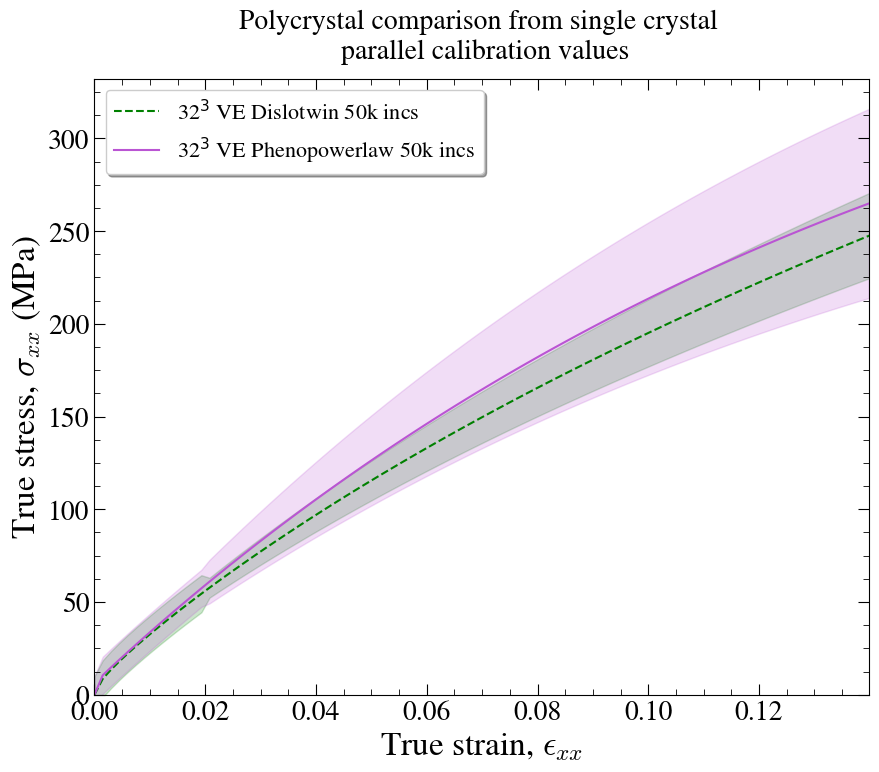

In [53]:
%matplotlib inline
fig = plt.figure(figsize = (10,8))
ax = fig.add_subplot(1,1,1)

ax.set_title('Polycrystal comparison from single crystal \n parallel calibration values', fontsize = 20, pad = 15)
ax.plot(dislo_32_true_strain, dislo_32_true_stress_MPa, label = '32$^{3}$ VE Dislotwin 50k incs', ls = '--', marker = 'None', color = 'green', ms = 12)
ax.plot(pheno_32_true_strain, pheno_32_true_stress_MPa, label = '32$^{3}$ VE Phenopowerlaw 50k incs', ls = '-', marker = 'None', color = 'mediumorchid', ms = 12)
ax.fill_between(dislo_32_true_strain, dislo_32_true_stress_MPa - 2*dislo_exp_err, dislo_32_true_stress_MPa + 2*dislo_exp_err, color = 'green', alpha = 0.2)
ax.fill_between(pheno_32_true_strain, pheno_32_true_stress_MPa - 2*pheno_exp_err, pheno_32_true_stress_MPa + 2*pheno_exp_err, color = 'mediumorchid', alpha = 0.2)
#ax.plot(pheno_32_50k_true_strain, pheno_32_50k_true_stress/(1e6*np.ones(len(pheno_32_50k_true_stress))), label = '32 VE Phenopowerlaw 50k incs', ls = '-.', marker = 'None', color = 'magenta', ms = 12)
#ax.plot(dislo_32_50k_true_strain, dislo_32_50k_true_stress/(1e6*np.ones(len(dislo_32_50k_true_stress))), label = '32 VE Dislotwin 50k incs', ls = '-.', marker = 'None', color = 'limegreen', ms = 12)

ax.set_xlabel('True strain, $\epsilon_{xx}$', fontsize = 24, math_fontfamily = 'cm')
ax.set_ylabel('True stress, $\sigma_{xx}$ (MPa)', fontsize = 24, math_fontfamily = 'cm')
ax.set_xlim(0, max(max(dislo_32_true_strain), max(pheno_32_true_strain)))
ax.set_ylim(0)
ax.tick_params(which = 'both', direction = 'in', top = True, right = True, labelsize = 20)
ax.tick_params(which = 'minor', length = 4)
ax.tick_params(which = 'major', length = 8)
ax.xaxis.set_minor_locator(AutoMinorLocator(4))
ax.yaxis.set_minor_locator(AutoMinorLocator(4))

ax.legend(fontsize = 16, shadow = True)
plt.show()

In [ ]:
#print(pheno_32_true_stress_MPa, dislo_32_true_stress_MPa)
((pheno_32_true_stress_MPa-dislo_32_true_stress_MPa)/dislo_32_true_stress_MPa)*100

Strain map from central layer

In [9]:
def xy_strain_maps(file, rve_shape, layer):

    result = damask.Result(file)

    try:
        result.add_strain()
        result.add_stress_Cauchy()
        result.add_IPF_color(l=(0,0,1))

    except:
        pass

    increment = result.increments[-1]

    x = result.view(increments = increment)

    strain_map_array = x.place('epsilon_V^0.0(F)')[:,0,0].reshape(rve_shape,order='F')[:,:,layer].transpose()
    strain_map_array_flip_y = np.flip(strain_map_array, axis=0)
    #strain_map_array_flipped = np.flip(strain_map_array_flip_y, axis=1)

    return strain_map_array_flip_y

In [10]:
dislo_strain_map = xy_strain_maps(dislo_file, rve_shape = [32,32,32], layer = 15)
pheno_strain_map = xy_strain_maps(pheno_file, rve_shape = [32,32,32], layer = 15)

In [ ]:
#fig_pheno_strain, ax_pheno_strain = plt.subplots(1,1, figsize = (10,6))

#pheno_32_strain_im = ax_pheno_strain.imshow(pheno_strain_map)
#pheno_32_cbar = fig_pheno_strain.colorbar(pheno_32_strain_im, orientation = 'vertical')
#pheno_32_cbar.set_label('True strain, $\epsilon_{xx}$', rotation = 90, fontsize = 16)
#ax_pheno_strain.set_xticks([])
#ax_pheno_strain.set_yticks([])


[]

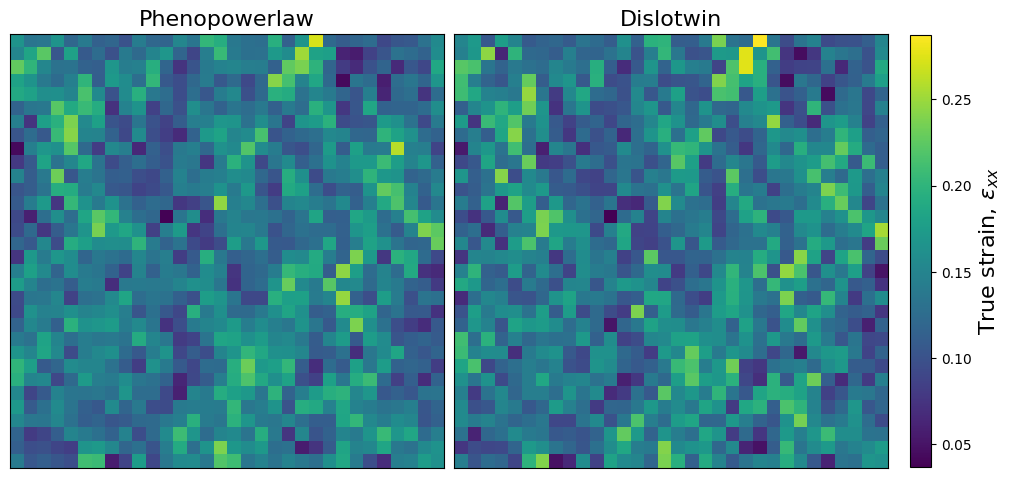

In [11]:
%matplotlib inline

fig_strain, ax_strain = plt.subplots(1,2, figsize = (10,6), sharey = True, sharex=True, constrained_layout=True)

pheno_strain_im = ax_strain[0].imshow(pheno_strain_map, vmin = min(min(value) for value in (pheno_strain_map.flatten(), dislo_strain_map.flatten())), vmax = max(max(value) for value in (pheno_strain_map.flatten(), dislo_strain_map.flatten())))
dislo_strain_im = ax_strain[1].imshow(dislo_strain_map, vmin = min(min(value) for value in (pheno_strain_map.flatten(), dislo_strain_map.flatten())), vmax = max(max(value) for value in (pheno_strain_map.flatten(), dislo_strain_map.flatten())))
#cbar1 = fig.colorbar(pheno_strain_im, orientation = 'vertical')
cbar2 = fig_strain.colorbar(dislo_strain_im, orientation = 'vertical', shrink = 0.73)
#cbar1.set_label('True strain, $\epsilon_{xx}$', rotation = 90, fontsize = 16)
cbar2.set_label('True strain, $\epsilon_{xx}$', rotation = 90, fontsize = 16)
ax_strain[0].set_title('Phenopowerlaw', fontsize = 16)
ax_strain[1].set_title('Dislotwin', fontsize = 16)
ax_strain[0].set_xticks([])
ax_strain[1].set_xticks([])
ax_strain[0].set_yticks([])
ax_strain[1].set_yticks([])

In [16]:
dislo_central_layer_strains = dislo_strain_map.flatten()
pheno_central_layer_strains = pheno_strain_map.flatten()

In [105]:
r2_score_strain = sklearn.metrics.r2_score(pheno_central_layer_strains, dislo_central_layer_strains)
dot_product_strain = np.dot(pheno_central_layer_strains, dislo_central_layer_strains)
norm_dot_product_strain = dot_product_strain/(np.linalg.norm(pheno_central_layer_strains)*np.linalg.norm(dislo_central_layer_strains))

In [106]:
norm_dot_product_strain

0.992184941535395

In [82]:
# Comparison plot
def comparison_plot(pheno_data, dislo_data, xlabel, ylabel, r2_score, annotation_pos):

    fig_comp, ax_comp = plt.subplots(1,1, figsize = (12,8))

    ax_comp.plot(pheno_data, dislo_data, 'ko', ls = 'None', label = 'CP model predictions', alpha = 0.2)
    ax_comp.axline([0,0], slope = 1, color = 'r', label = 'Equal predictions')
    ax_comp.set_xlabel(fr'{xlabel}', fontsize = 24, math_fontfamily = 'cm')
    ax_comp.set_ylabel(fr'{ylabel}', fontsize = 24, math_fontfamily = 'cm')
    ax_comp.tick_params(which = 'both', direction = 'in', top = True, right = True, labelsize = 20)
    ax_comp.tick_params(which = 'minor', length = 4)
    ax_comp.tick_params(which = 'major', length = 8)
    ax_comp.xaxis.set_minor_locator(AutoMinorLocator(5))
    ax_comp.yaxis.set_minor_locator(AutoMinorLocator(5))
    ax_comp.annotate(f'$r^2$ = {r2_score:.3f}', xy = annotation_pos, fontsize = 16, math_fontfamily = 'cm')
    ax_comp.legend(shadow = True, fontsize  = 16)


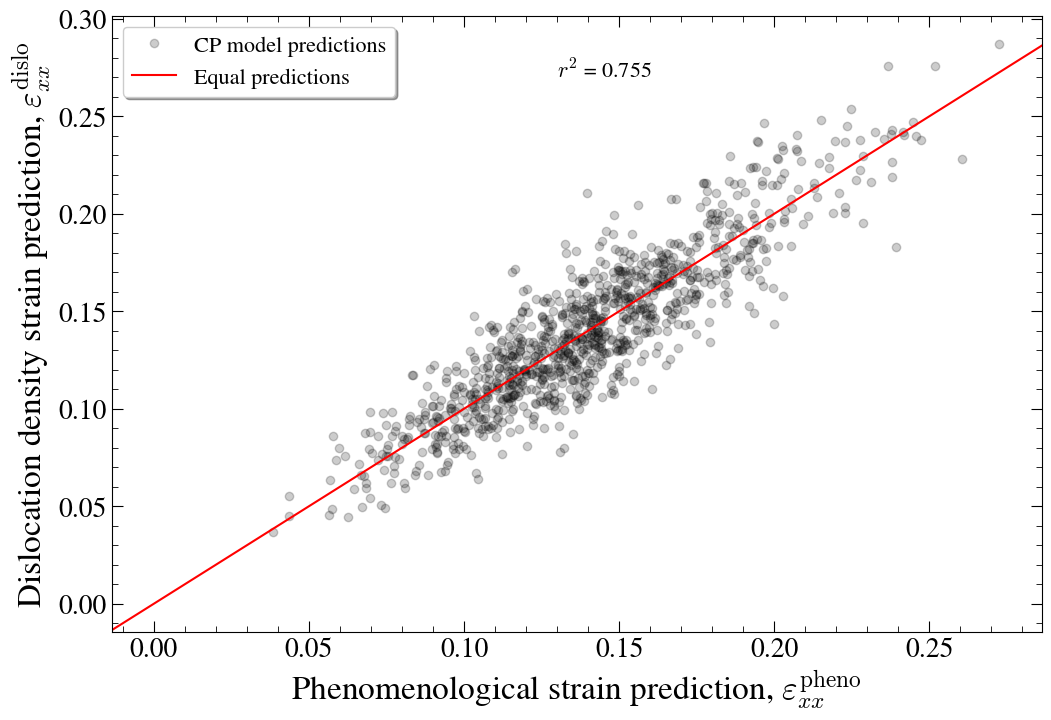

In [108]:
comparison_plot(pheno_central_layer_strains, dislo_central_layer_strains, 
                xlabel = r'Phenomenological strain prediction, $\varepsilon_{xx}^{\text{pheno}}$',
                ylabel = r'Dislocation density strain prediction, $\varepsilon_{xx}^{\text{dislo}}$',
                r2_score = r2_score_strain,
                annotation_pos = (0.13,0.27))

Stress triaxiality

In [72]:
def calc_triaxiality(file, rve_shape, layer):
    result = damask.Result(file)

    try:
        result.add_spherical('sigma')
        result.add_equivalent_Mises('sigma')
    
    except:
        pass

    x = result.view(increments = result.increments[-1])

    #print(x.place('p_sigma'))
    #print(len(x.place('p_sigma')))
    hydrostatic_stress = x.place('p_sigma').reshape(rve_shape,order='F')[:,:,layer].transpose()
    vM_stress = x.place('sigma_vM').reshape(rve_shape,order='F')[:,:,layer].transpose()

    hydrostatic_stress_flipped = np.flip(hydrostatic_stress, axis=0)
    vM_stress_flipped = np.flip(vM_stress, axis=0)

    triaxiality = hydrostatic_stress_flipped/vM_stress_flipped

    return triaxiality

In [73]:
dislo_triax_map = calc_triaxiality(dislo_file, rve_shape=[32,32,32], layer = 15)
pheno_triax_map = calc_triaxiality(pheno_file, rve_shape=[32,32,32], layer = 15)

In [ ]:
#fig_pheno_triax, ax_pheno_triax = plt.subplots(1,1, figsize = (10,6))

#pheno_32_triax_im = ax_pheno_triax.imshow(pheno_triax_map)
#pheno_32_triax_cbar = fig_pheno_triax.colorbar(pheno_32_triax_im, orientation = 'vertical')
#pheno_32_triax_cbar.set_label('Stress triaxiality, $T_{\sigma,xx}$', rotation = 90, fontsize = 16)
#ax_pheno_triax.set_xticks([])
#ax_pheno_triax.set_yticks([])


[]

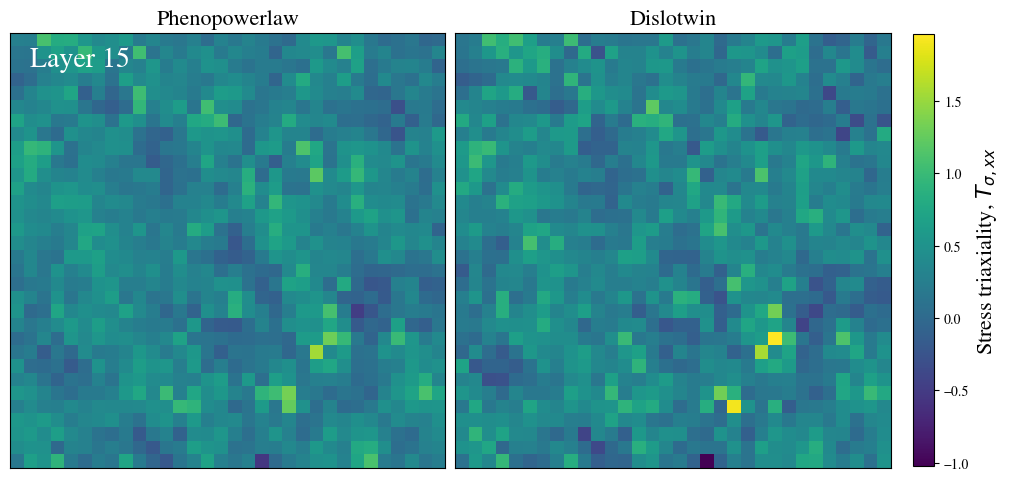

In [74]:
%matplotlib inline

fig_triax, ax_triax = plt.subplots(1,2, figsize = (10,6), sharey=True, sharex=True, constrained_layout=True)

pheno_triax_im = ax_triax[0].imshow(pheno_triax_map, vmin = min(min(value) for value in (pheno_triax_map.flatten(), dislo_triax_map.flatten())), vmax = max(max(value) for value in (pheno_triax_map.flatten(), dislo_triax_map.flatten())))
dislo_triax_im = ax_triax[1].imshow(dislo_triax_map, vmin = min(min(value) for value in (pheno_triax_map.flatten(), dislo_triax_map.flatten())), vmax = max(max(value) for value in (pheno_triax_map.flatten(), dislo_triax_map.flatten())))
cbar_triax = fig_triax.colorbar(dislo_triax_im, orientation = 'vertical', shrink=0.73)
#cbar1.set_label('True strain, $\epsilon_{xx}$', rotation = 90, fontsize = 16)
cbar_triax.set_label('Stress triaxiality, $T_{\sigma,xx}$', rotation = 90, fontsize = 16)
ax_triax[0].annotate(text = 'Layer 15', xy = [1,2], color = 'w', fontsize = 20)
ax_triax[0].set_title('Phenopowerlaw', fontsize = 16)
ax_triax[1].set_title('Dislotwin', fontsize = 16)
ax_triax[0].set_xticks([])
ax_triax[1].set_xticks([])
ax_triax[0].set_yticks([])
ax_triax[1].set_yticks([])

In [78]:
pheno_central_layer_triax = pheno_triax_map.flatten()
dislo_central_layer_triax = dislo_triax_map.flatten()

In [110]:
r2_score_triax = sklearn.metrics.r2_score(pheno_central_layer_triax, dislo_central_layer_triax)
dot_product_triax = np.dot(pheno_central_layer_triax, dislo_central_layer_triax)
norm_dot_product_triax = dot_product_triax/(np.linalg.norm(pheno_central_layer_triax)*np.linalg.norm(dislo_central_layer_triax))

In [111]:
norm_dot_product_triax

0.9407362122503526

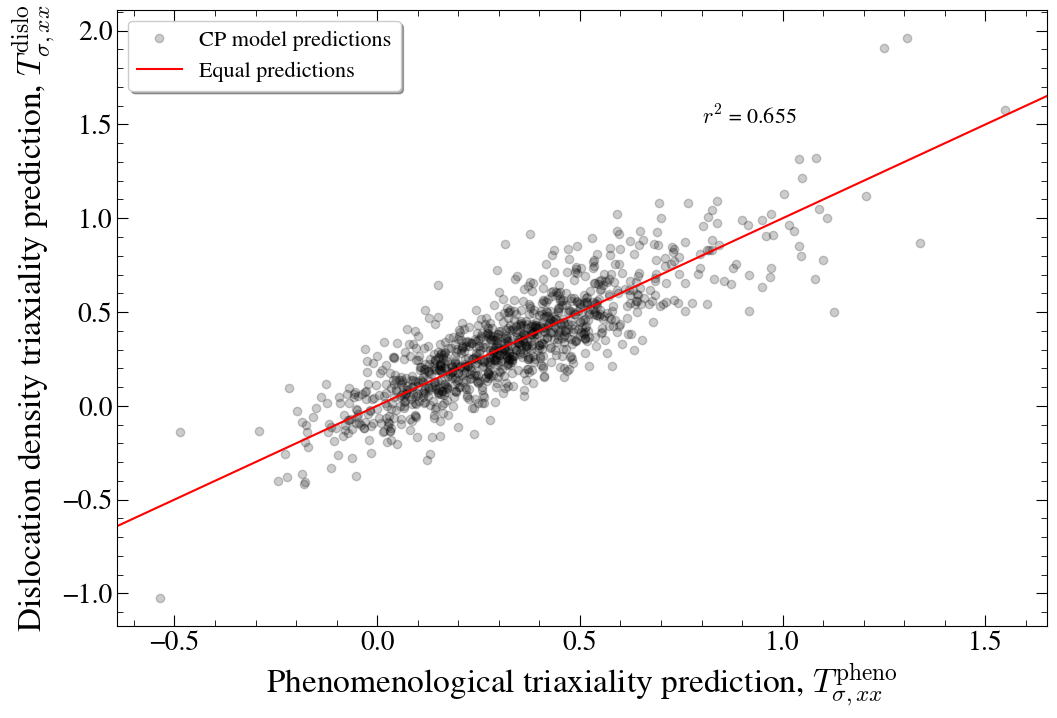

In [84]:
comparison_plot(pheno_central_layer_triax, dislo_central_layer_triax,
                xlabel= r'Phenomenological triaxiality prediction, $T_{\sigma,xx}^{\text{pheno}}$',
                ylabel= r'Dislocation density triaxiality prediction, $T_{\sigma,xx}^{\text{dislo}}$',
                r2_score= r2_score_triax,
                annotation_pos = (0.8,1.5))

Animation of stress triaxiality through VE

In [ ]:
from matplotlib.animation import FuncAnimation

In [ ]:
rve_shape = [32,32,32]
xy_pheno_triax_layers = []
xy_dislo_triax_layers = []
for i in range(32):
    xy_pheno_triax = calc_triaxiality(pheno_file, rve_shape, layer = i)
    xy_dislo_triax = calc_triaxiality(dislo_file, rve_shape, layer = i)
    xy_pheno_triax_layers.append(xy_pheno_triax)
    xy_dislo_triax_layers.append(xy_dislo_triax)

In [ ]:
min(min(value) for value in (np.array(xy_pheno_triax_layers).flatten(), np.array(xy_dislo_triax_layers).flatten()))

In [ ]:
max(max(value) for value in (np.array(xy_pheno_triax_layers).flatten(), np.array(xy_dislo_triax_layers).flatten()))

In [ ]:
[min(min(value) for value in (xy_pheno_triax_layers[0].flatten(), xy_dislo_triax_layers[0].flatten()))]

In [ ]:
#Initial image
fig0, ax0 = plt.subplots(1,2, figsize = (10,6), sharey=True, sharex=True, constrained_layout=True)
pheno_triax_im = ax0[0].imshow(xy_pheno_triax_layers[0], vmin = min(min(value) for value in (np.array(xy_pheno_triax_layers).flatten(), np.array(xy_dislo_triax_layers).flatten())), vmax = max(max(value) for value in (np.array(xy_pheno_triax_layers).flatten(), np.array(xy_dislo_triax_layers).flatten())))
dislo_triax_im = ax0[1].imshow(xy_dislo_triax_layers[0], vmin = min(min(value) for value in (np.array(xy_pheno_triax_layers).flatten(), np.array(xy_dislo_triax_layers).flatten())), vmax = max(max(value) for value in (np.array(xy_pheno_triax_layers).flatten(), np.array(xy_dislo_triax_layers).flatten())))
cbar_triax = fig0.colorbar(dislo_triax_im, orientation = 'vertical', shrink=0.73)
cbar_triax.set_label('Stress triaxiality, $T_{\sigma,xx}$', rotation = 90, fontsize = 16)
layer_annot = ax0[0].annotate(text = 'Layer 1', xy = [1,2], color = 'w', fontsize = 20)
ax0[0].set_title('Phenopowerlaw', fontsize = 16)
ax0[1].set_title('Dislotwin', fontsize = 16)
ax0[0].set_xticks([])
ax0[0].set_yticks([])
ax0[1].set_xticks([])
ax0[1].set_yticks([])

In [ ]:
def xy_triax_update(frame):
    pheno_triax_im.set_array(xy_pheno_triax_layers[frame])# vmin = min(min(value) for value in (xy_pheno_triax_layers[frame].flatten(), xy_dislo_triax_layers[frame].flatten())), vmax = max(max(value) for value in (xy_pheno_triax_layers[frame].flatten(), xy_dislo_triax_layers[frame].flatten())))
    dislo_triax_im.set_array(xy_dislo_triax_layers[frame])# vmin = min(min(value) for value in (xy_pheno_triax_layers[frame].flatten(), xy_dislo_triax_layers[frame].flatten())), vmax = max(max(value) for value in (xy_pheno_triax_layers[frame].flatten(), xy_dislo_triax_layers[frame].flatten())))
    dislo_triax_im.set_clim(vmin = min(min(value) for value in (np.array(xy_pheno_triax_layers).flatten(), np.array(xy_dislo_triax_layers).flatten())), vmax = max(max(value) for value in (np.array(xy_pheno_triax_layers).flatten(), np.array(xy_dislo_triax_layers).flatten())))
    #cbar_triax.update_normal(dislo_triax_im)
    layer_annot.set_text(f'Layer {frame+1}')

    return pheno_triax_im, dislo_triax_im, layer_annot

In [ ]:
fig0.set_constrained_layout(False)
xy_triax_maps_ani = FuncAnimation(fig0, xy_triax_update, frames=len(xy_pheno_triax_layers), blit=False, repeat=False)
xy_triax_maps_ani.save('xy_pheno_and_dislo_32_triax.gif', fps=10)

In [ ]:
class MapAnimations():
    # Extracting key values from simulations
    def extract_strain_maps(file, rve_shape, layer, direction):

        '''
        Extract and plot strain maps from DAMASK HDF5 file

        direction: {'xy', 'yz', 'xz'}
        
        '''

        result = damask.Result(file)

        try:
            result.add_strain()
            result.add_stress_Cauchy()
            result.add_IPF_color(l=(0,0,1))

        except:
            pass

        increment = result.increments[-1]

        x = result.view(increments = increment)

        if direction == 'xy':
            strain_map_array = x.place('epsilon_V^0.0(F)')[:,0,0].reshape(rve_shape,order='F')[:,:,layer].transpose()

        if direction == 'yz':
            strain_map_array = x.place('epsilon_V^0.0(F)')[:,0,0].reshape(rve_shape,order='F')[layer,:,:].transpose()

        if direction == 'xz':
            strain_map_array = x.place('epsilon_V^0.0(F)')[:,0,0].reshape(rve_shape,order='F')[:,layer,:].transpose()

        strain_map_array_flip_y = np.flip(strain_map_array, axis=0)
        #strain_map_array_flipped = np.flip(strain_map_array_flip_y, axis=1)

        return strain_map_array_flip_y

    def calc_triaxiality(file, rve_shape, layer, direction):
        result = damask.Result(file)

        try:
            result.add_spherical('sigma')
            result.add_equivalent_Mises('sigma')
        
        except:
            pass

        x = result.view(increments = result.increments[-1])

        if direction == 'xy':
            hydrostatic_stress = x.place('p_sigma').reshape(rve_shape,order='F')[:,:,layer].transpose()
            vM_stress = x.place('sigma_vM').reshape(rve_shape,order='F')[:,:,layer].transpose()
        
        if direction == 'yz':
            hydrostatic_stress = x.place('p_sigma').reshape(rve_shape,order='F')[layer,:,:].transpose()
            vM_stress = x.place('sigma_vM').reshape(rve_shape,order='F')[layer,:,:].transpose()

        if direction == 'xz':
            hydrostatic_stress = x.place('p_sigma').reshape(rve_shape,order='F')[:,layer,:].transpose()
            vM_stress = x.place('sigma_vM').reshape(rve_shape,order='F')[:,layer,:].transpose()

        hydrostatic_stress_flipped = np.flip(hydrostatic_stress, axis=0)
        vM_stress_flipped = np.flip(vM_stress, axis=0)

        triaxiality = hydrostatic_stress_flipped/vM_stress_flipped

        return triaxiality
    
    def calc_plastic_work(file, rve_shape, layer, direction):
        result = damask.Result(file)

        try:
            result.add_stress_second_Piola_Kirchhoff()
        except:
            pass

        x = result.view(increments = result.increments[-1])


    def update(frame):
        pheno_triax_im.set_array(xy_pheno_triax_layers[frame])
        dislo_triax_im.set_array(xy_dislo_triax_layers[frame])
        dislo_triax_im.set_clim(vmin = min(min(value) for value in (np.array(xy_pheno_triax_layers).flatten(), np.array(xy_dislo_triax_layers).flatten())), vmax = max(max(value) for value in (np.array(xy_pheno_triax_layers).flatten(), np.array(xy_dislo_triax_layers).flatten())))
        #cbar_triax.update_normal(dislo_triax_im)
        layer_annot.set_text(f'Layer {frame+1}')

        return pheno_triax_im, dislo_triax_im, layer_annot

# Calculating plastic work = $\tau \gamma$

Only along the first slip system labelled in DAMASK for now

In [85]:
def calc_plastic_work_xy(damask_file, mat_file, rve_shape, slip_system, layer):
    result = damask.Result(damask_file)
    x = result.view(increments = result.increments[-1])
    gamma = x.place('gamma_sl')[:,slip_system].reshape(rve_shape, order = 'F')[:,:,layer].transpose() #shear on first slip system on xy face

    mat = damask.ConfigMaterial.load(mat_file)
    crystal_structure = damask.Crystal(lattice = mat['phase']['Cu']['lattice'])
    slip_dirs = crystal_structure.kinematics('slip')['direction'][slip_system]
    slip_norms = crystal_structure.kinematics('slip')['plane'][slip_system]

    rot_matrices = damask.Rotation(x.place('O')).as_matrix()

    # Calculate final orientations of material points

    all_new_slip_dirs = []
    all_new_slip_norms = []

    for i in range(len(rot_matrices)):
        new_slip_dirs = []
        new_slip_norms = []
        for j in range(len(slip_dirs)):
            new_slip_dir = rot_matrices[i] @ slip_dirs[j]
            new_slip_norm = rot_matrices[i] @ slip_norms[j]
            new_slip_dirs.append(new_slip_dir)
            new_slip_norms.append(new_slip_norm)
        
        all_new_slip_dirs.append(new_slip_dirs)
        all_new_slip_norms.append(new_slip_norms)

    sigma = x.place('sigma')
    
    # Calculate resolved shear stresses
    tau = np.einsum('vij,vsi,vsj->vs', sigma, all_new_slip_dirs, all_new_slip_norms)

    tau_slip = tau[:,slip_system].reshape(rve_shape, order = 'F')[:,:,layer].transpose()

    plastic_work = np.multiply(gamma, tau_slip)

    return plastic_work
    

In [86]:
dislo_mat_file = './dislo_density/second_year_report_calibrated_values/dislotwin_32_rolled_copper_2026-06-19_120653/execute/t_1/material.yaml'
pheno_mat_file = './phenopowerlaw/second_year_report_calibrated_values/phenopowerlaw_32_rolled_copper_2026-06-19_120033/execute/t_1/material.yaml'

dislo_plastic_work_xy_1 = calc_plastic_work_xy(dislo_file, dislo_mat_file, rve_shape=[32,32,32], slip_system = 1, layer = 15)
pheno_plastic_work_xy_1 = calc_plastic_work_xy(pheno_file, pheno_mat_file, rve_shape=[32,32,32], slip_system = 1, layer = 15)

[]

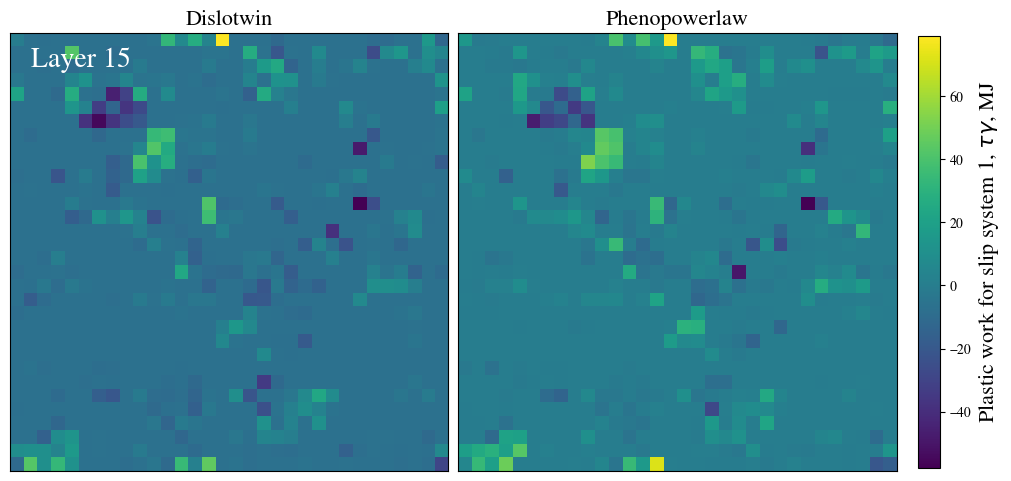

In [87]:
fig_pw_1, ax_pw_1 = plt.subplots(1,2, figsize = (10,6), sharey=True, sharex=True, constrained_layout=True)


dislo_pw_xy_1_im = ax_pw_1[0].imshow(dislo_plastic_work_xy_1/(np.ones_like(dislo_plastic_work_xy_1)*1e6))
pheno_pw_xy_1_im = ax_pw_1[1].imshow(pheno_plastic_work_xy_1/(np.ones_like(pheno_plastic_work_xy_1)*1e6))

cbar_pw_xy_1 = fig_pw_1.colorbar(pheno_pw_xy_1_im, orientation = 'vertical', shrink = 0.73)

cbar_pw_xy_1.set_label(r'Plastic work for slip system 1, $\tau\gamma$, MJ', rotation = 90, fontsize = 16)

ax_pw_1[0].annotate(text = 'Layer 15', xy = [1,2], color = 'w', fontsize = 20)
ax_pw_1[0].set_title('Dislotwin', fontsize = 16)
ax_pw_1[1].set_title('Phenopowerlaw', fontsize = 16)

ax_pw_1[0].set_xticks([])
ax_pw_1[1].set_xticks([])
ax_pw_1[0].set_yticks([])
ax_pw_1[1].set_yticks([])

In [94]:
pheno_plastic_work_xy_sl_1_MJ = (pheno_plastic_work_xy_1/(np.ones_like(dislo_plastic_work_xy_1)*1e6)).flatten()
dislo_plastic_work_xy_sl_1_MJ = (dislo_plastic_work_xy_1/(np.ones_like(dislo_plastic_work_xy_1)*1e6)).flatten()

In [112]:
r2_score_plastic_work_xy_sl_1 = sklearn.metrics.r2_score(pheno_plastic_work_xy_sl_1_MJ, dislo_plastic_work_xy_sl_1_MJ)
dot_product_plastic_work_xy_sl_1 = np.dot(pheno_plastic_work_xy_sl_1_MJ, dislo_plastic_work_xy_sl_1_MJ)
norm_dot_product_plastic_work_xy_sl_1 = dot_product_plastic_work_xy_sl_1/(np.linalg.norm(pheno_plastic_work_xy_sl_1_MJ)*np.linalg.norm(dislo_plastic_work_xy_sl_1_MJ))

In [113]:
norm_dot_product_plastic_work_xy_sl_1

0.8744688926609612

Text(0, 0.5, 'Dislocation density plastic work prediction for slip system 1, $\\tau\\gamma$ (MJ)')

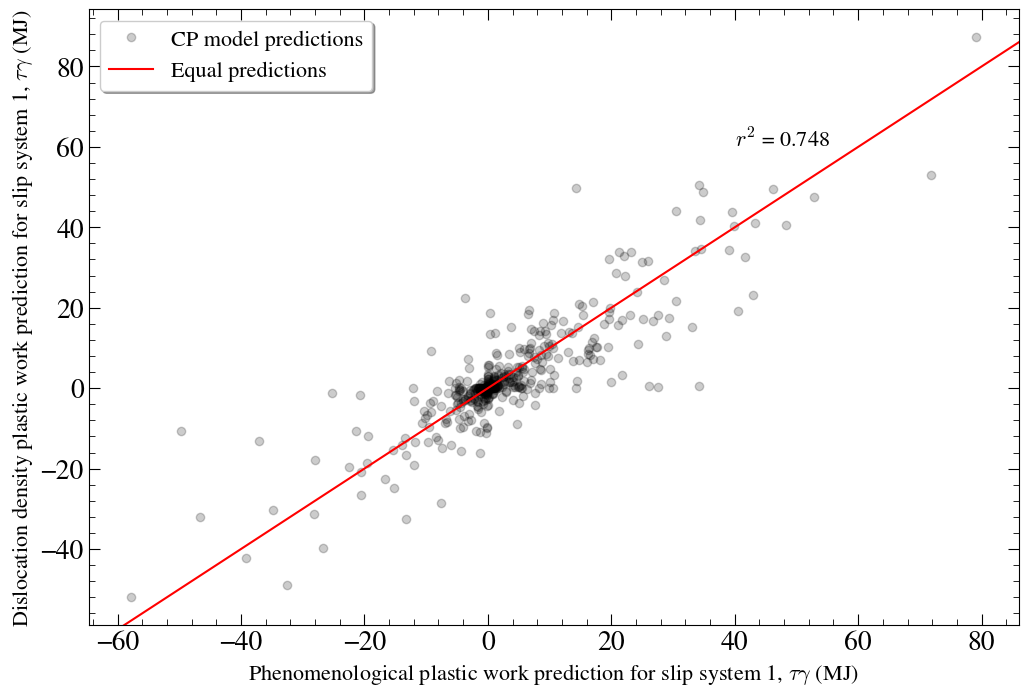

In [101]:
comparison_plot(pheno_plastic_work_xy_sl_1_MJ, dislo_plastic_work_xy_sl_1_MJ,
                xlabel= r'Phenomenological plastic work prediction for slip system 1, $\tau\gamma$ (MJ)',
                ylabel= r'Dislocation density plastic work prediction for slip system 1, $\tau\gamma$ (MJ)',
                r2_score=r2_score_plastic_work_xy_sl_1,
                annotation_pos=(40,60))
plt.xlabel(r'Phenomenological plastic work prediction for slip system 1, $\tau\gamma$ (MJ)', fontsize = 16)
plt.ylabel(r'Dislocation density plastic work prediction for slip system 1, $\tau\gamma$ (MJ)', fontsize = 16)

# Calculation of r-value

Cannot add results from plastic part of def grad $F_p$ unless specified in post-processing in matflow script

In [ ]:
# Option 1, r-value from local plastic strain

def calc_r_value(damask_file):
    result = damask.Result(damask_file)
    try:
        result.add_strain('F_p','U')
        result.add_stretch_tensor('F_p',t='U')
    except:
        pass
    plastic_strain = np.array([np.average(eps,0) for eps in result.get('epsilon_U^0.0(F_p)').values()])
    r_eps_p = plastic_strain[:,1,1]/plastic_strain[:,2,2]

    U_p_avg = np.array([np.average(U_p,0) for U_p in result.get('U(F_p)').values()])
    epsilon_F_p_avg = damask.mechanics.strain(U_p_avg,t='U',m=0.0)
    epsilon_F_p_vM_avg = damask.mechanics.equivalent_strain_Mises(epsilon_F_p_avg)

    return epsilon_F_p_vM_avg, r_eps_p

In [ ]:
pheno_vM_strain, pheno_r_val = calc_r_value(pheno_file)
dislo_vM_strain, dislo_r_val = calc_r_value(dislo_file)

fig_r_val, ax_r_val = plt.subplots(1,1, figsize = (10,6))

ax_r_val.plot(pheno_vM_strain, pheno_r_val, ls = '--', label = 'Phenopowerlaw')
ax_r_val.plot(dislo_vM_strain, dislo_r_val, ls = '-', label = 'Dislotwin')
ax_r_val.set_xlabel('von Mises strain')
ax_r_val.set_ylabel('r-value')

ax_r_val.legend(shadow = True)

In [ ]:
pheno_demo_result = damask.Result(pheno_file)
#pheno_demo_result.add_strain('F','U')
pheno_demo_result.add_strain('F_p','U')
#pheno_demo_result.add_stretch_tensor('F',t='U')
pheno_demo_result.view(increments = pheno_demo_result.increments[-1])

# Original determination of plastic work prior to above function

In [ ]:
dislo_result = damask.Result(dislo_file)
pheno_result = damask.Result(pheno_file)
dislo_x = dislo_result.view(increments = dislo_result.increments[-1])
pheno_x = pheno_result.view(increments = pheno_result.increments[-1])
gamma_0_dislo = dislo_x.place('gamma_sl')[:,0].reshape(rve_shape, order = 'F')[:,:,0].transpose()
gamma_0_dislo = dislo_x.place('gamma_sl')[:,0].reshape(rve_shape, order = 'F')[:,:,0].transpose()

Resolved shear stress on slip system $\alpha$ is $\tau^{\alpha} = S : (n^{\alpha} \otimes s^{\alpha})$ with n and s defined in undeformed configuration, or $\tau^{\alpha} = \sigma : (n^{\alpha} \otimes s^{\alpha})$ with n and s defined in current configuration

Since we are using the result file, final orientations are easier access and so the second calculation should be performed

In [ ]:
dislo_x.place('sigma').shape


In [ ]:
dislo_x.place('O')#.reshape([32,32,32], order = 'F')

Find slip systems

In [ ]:
dislo_mat_file = './dislo_density/5k_time_steps/dislotwin_32_rolled_copper_2026-06-02_094034/execute/t_1/material.yaml'
dislo_mat = damask.ConfigMaterial.load(dislo_mat_file)
crystal_structure = damask.Crystal(lattice = dislo_mat['phase']['Cu']['lattice'])
slip_dirs = crystal_structure.kinematics('slip')['direction'][0]
slip_norms = crystal_structure.kinematics('slip')['plane'][0]

Convert quaternions to rotation matrices

In [ ]:
print(damask.Rotation(dislo_x.place('O')[1]).as_matrix())
rot_matrices = damask.Rotation(dislo_x.place('O')).as_matrix()
print(rot_matrices, len(rot_matrices))

In [ ]:
print(np.array(rot_matrices[0]).dot(np.array(slip_dirs[0])))

all_new_slip_dirs = []
all_new_slip_norms = []

for i in range(len(rot_matrices)):
    new_slip_dirs = []
    new_slip_norms = []
    for j in range(len(slip_dirs)):
        new_slip_dir = rot_matrices[i] @ slip_dirs[j]
        new_slip_norm = rot_matrices[i] @ slip_norms[j]
        new_slip_dirs.append(new_slip_dir)
        new_slip_norms.append(new_slip_norm)
        
    all_new_slip_dirs.append(new_slip_dirs)
    all_new_slip_norms.append(new_slip_norms)


In [ ]:
np.array(all_new_slip_dirs).shape, np.array(all_new_slip_norms).shape

In [ ]:
sigma = dislo_x.place('sigma')

In [ ]:
# Calculate resolved shear stresses
tau = np.einsum('vij,vsi,vsj->vs', sigma, all_new_slip_dirs, all_new_slip_norms)

In [ ]:
tau[:,0]

Extract $\tau$ for slip system 1 at the first xy slice

In [ ]:
tau_0 = tau[:,0].reshape(rve_shape, order = 'F')[:,:,0].transpose()

In [ ]:
dislo_plastic_work = np.multiply(gamma_0, tau_0)

In [ ]:
dislo_plastic_work.shape

In [ ]:
fig_pw, ax_pw = plt.subplots(1,1, figsize = (10,6))

dislo_pw = ax_pw.imshow(dislo_plastic_work)

cbar_pw = fig_pw.colorbar(dislo_pw, orientation = 'vertical')

cbar_pw.set_label(r'Plastic work for slip system 1, $\tau\gamma$', rotation = 90, fontsize = 16)

ax_pw.set_xticks([])
ax_pw.set_yticks([])